# Video Classification

This notebook explores how videos were classified and how video classes are distributed across recordings.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from utils.dataset import DataSet


Define the paths used to access data, metadata, and intermediate results.

Initialize a `DataSet` object to handle the full dataset.

Use `metadata` as `folder_metadata`.

Load trial metadata from JSON files with metadata per trial in `folder_metadata` .

In [2]:
# base folder
folder_data = repo_root / 'data'

# results folder
folder_metadata = repo_root / 'metadata'

# mice/recording folders
all_recording_folders = [
    'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20',
]

# Inizialize and object from DataSet to handle the dataset
ds = DataSet(folder_data, 
              folder_metadata=folder_metadata, 
              recording=all_recording_folders,
              trials_metadata_file_type="json",
              trials_metadata_subfolder = "videos",
              check=True,
              verbose=True)

# Load the metadata for all trials
trials_df = ds.get_trials_metadata()

# Mapping from recording name to rec-animalID-session-scan format
mapping = {}
for rec in ds.recording:
    x = rec.split("-")
    mapping[rec] = f"rec-{ds.info[rec]['animal_id']}-{ds.info[rec]['session']}-{ds.info[rec]['scan_idx']}"


Initializing DataSet -------------------------------------------------------------------------------

Checking the data ----------------------------------------------------------------------------------
 > All data files seem consistent across trials and data types for recording dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9

## Check classification performance

### Unclassified trials

Compute the number of trials labeled as `unknown`.

In [3]:
n = np.sum(ds.trials_df['label']=="unknown")
print(f"Classification failed in {n} trials")

Classification failed in 0 trials


### Trials containing segments with bad properties

Compute the number of trials that include at least one segment with bad properties.

In [4]:
n = np.sum(ds.trials_df['segments_bad_n']>0)
print(f"{n} trials with bad segment properties detected")

2 trials with bad segment properties detected


Display the trials where bad segment properties were detected.

In [5]:
ds.trials_df[ds.trials_df['segments_bad_n']>0]

,recording,trial,trial_type,first_label,label,ID,sampling_freq,valid_frames,n_peaks,segments_n_peaks,segments_bad_n,segments_avg_duration
2592,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,668,live_test_bonus,NaturalImages,NaturalImages,None,30,403,19,20,1,20.15
6591,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,156,live_test_bonus,NaturalImages,NaturalImages,None,30,414,19,20,1,20.70


Load the videos corresponding to the trial with bad properties detected
Then, plot:
- frame-to-frame changes for the selected video
- example frames showing the issue
- the segment properties table

,frame_start,frame_end,duration,transition_start,transition_end,max_change,is_static,intensity_range,margin_left,margin_right,margin_top,margin_bottom,background_color,background_proportion,is_uniform,bad_properties
0,0,14,14,1,0,0.000000,True,0.000000,64,64,36,36,128.000000,0.996086,True,False
1,14,30,16,0,0,36.641811,True,166.750000,0,0,0,0,50.698040,0.019995,False,False
2,30,141,111,0,0,5.003804,True,11.980881,64,64,36,36,128.000000,0.988970,True,True
3,141,156,15,0,0,0.973294,True,249.812500,0,0,0,0,111.937256,0.019196,False,False
4,156,172,16,1,0,7.095246,True,10.480087,64,64,36,36,128.000000,0.937030,True,False
5,172,187,15,0,0,2.518336,True,242.000000,0,0,0,0,96.878433,0.011183,False,False
6,187,202,15,1,0,0.000000,True,0.000000,64,64,36,36,128.000000,0.996086,True,False
7,202,218,16,1,0,10.346995,True,233.625000,0,0,0,0,1.505883,0.054877,False,False
8,218,236,18,0,1,8.346907,True,7.640099,64,64,36,36,128.000000,0.942172,True,False
9,236,251,15,0,0,3.373837,True,210.812500,0,0,0,0,249.474518,0.011298,False,False


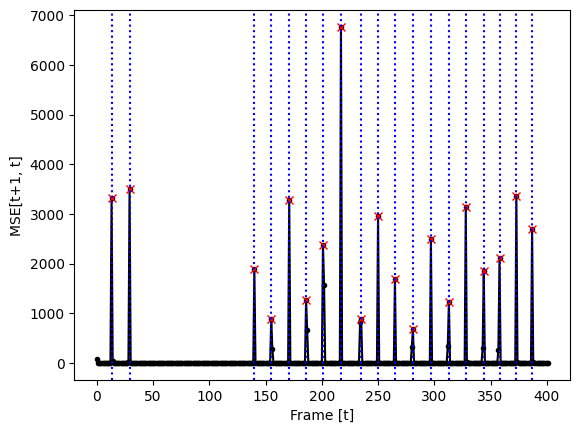

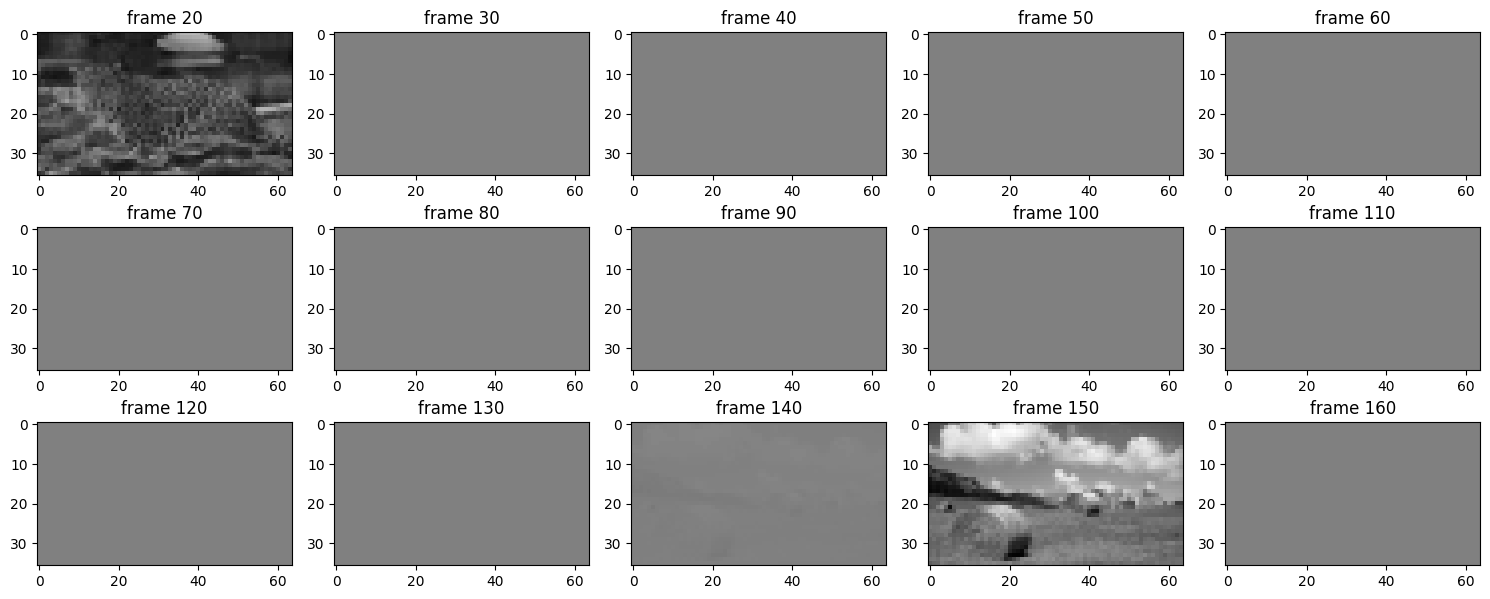

In [6]:
rec = 'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce'
trial = '668'
video = ds.load_video_by_trial(rec, trial)

# plot the changes in the video
fig, ax = video.plot_changes()
fig.savefig(Path(repo_root, 'figures', f"video-changes_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)

# plot some frames
frames_plot = np.arange(20, 170, 10).tolist()
fig, ax = video.plot_frames(frames_plot)
fig.savefig(Path(repo_root, 'figures', f"video-frames_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)

# display the video segments table
display(video.print_segments_table())


,frame_start,frame_end,duration,transition_start,transition_end,max_change,is_static,intensity_range,margin_left,margin_right,margin_top,margin_bottom,background_color,background_proportion,is_uniform,bad_properties
0,0,15,15,1,0,3.782476e+00,True,1.529386e+01,64,64,36,36,128.000000,0.942145,True,False
1,15,30,15,0,0,4.290819e-03,True,2.287500e+02,0,0,0,0,121.976471,0.023346,False,False
2,30,143,113,0,0,1.327558e+01,True,2.865206e+01,64,64,36,36,128.000000,0.988461,True,True
3,143,159,16,1,0,1.341934e+00,True,1.766250e+02,0,0,0,0,151.090196,0.027035,False,False
4,159,176,17,0,0,5.237187e+00,True,1.009515e+01,64,64,36,36,128.000000,0.920436,True,False
5,176,191,15,0,0,2.010454e+00,True,2.365625e+02,0,0,0,0,112.941176,0.015276,False,False
6,191,210,19,1,0,2.019484e-28,True,1.421085e-14,64,64,36,36,128.000000,0.996094,True,False
7,210,226,16,1,0,1.227463e+00,True,1.284375e+02,0,0,0,0,103.905882,0.016285,False,False
8,226,243,17,0,0,3.667399e+00,True,7.739776e+00,64,64,36,36,128.000000,0.902176,True,False
9,243,259,16,0,1,4.596293e+00,True,2.373750e+02,0,0,0,0,169.160784,0.016688,False,False


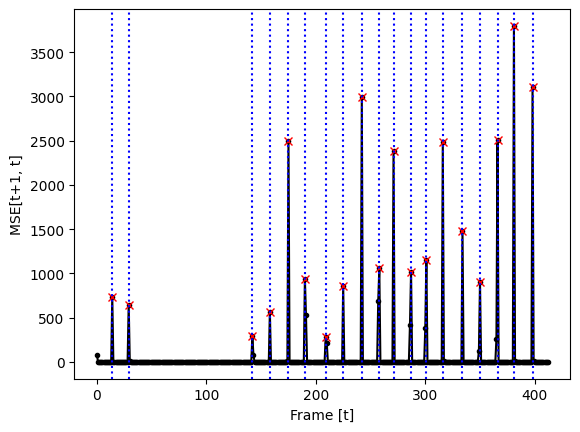

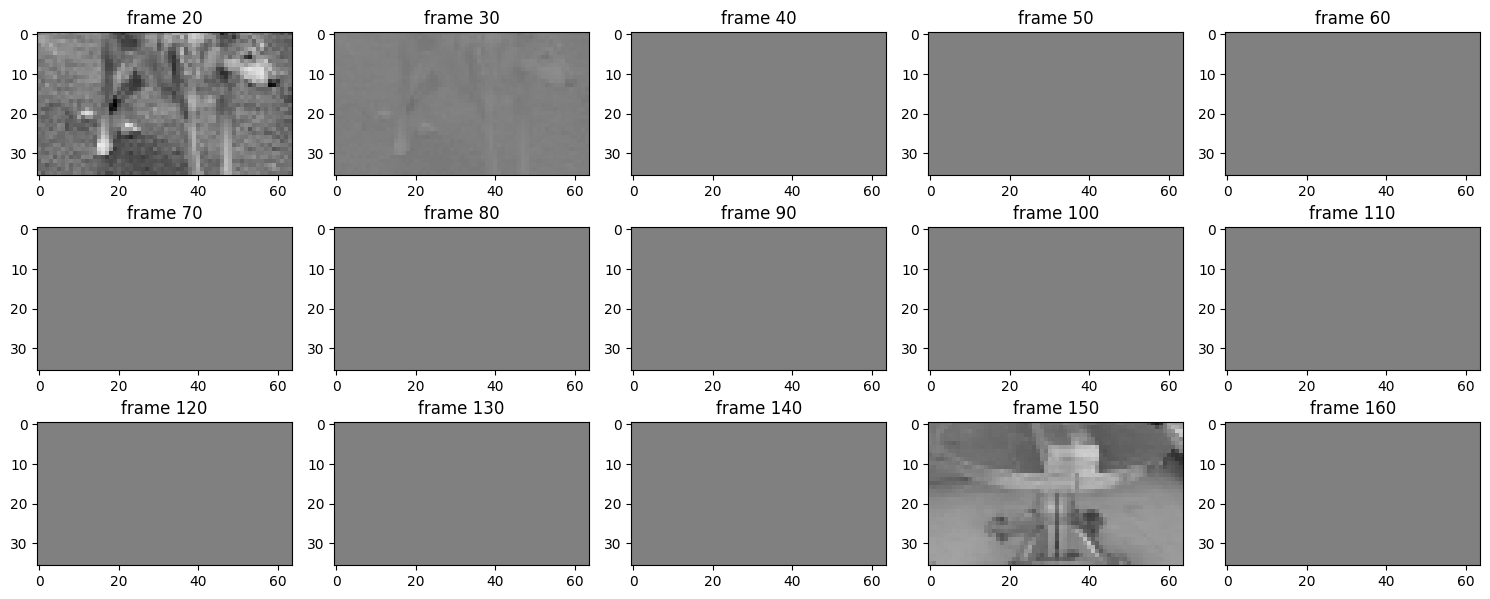

In [7]:
rec = 'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20'
trial = '156'
video = ds.load_video_by_trial(rec, trial)

# plot the changes in the video
fig, ax = video.plot_changes()
fig.savefig(Path(repo_root, 'figures', f"video-changes_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)

# plot some frames
frames_plot = np.arange(20, 170, 10).tolist()
fig, ax = video.plot_frames(frames_plot)
fig.savefig(Path(repo_root, 'figures', f"video-frames_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)

# display the video segments table
display(video.print_segments_table())


### Check changes between first and final classification

In [8]:
labels = ['NaturalVideo','NaturalImages','GaussianDot','Gabor','PinkNoise','RandomDots']
trials_df = ds.trials_df
errors = []
for label in labels:

    print(f'\nChanges in classification for label {label}...')
    df = trials_df[trials_df['label']==label]

    # get the number of differences between first and last classification
    idx = df['label'].to_numpy()!=df['first_label'].to_numpy()
    print(f"Number of changes in classification between first and last classification: {np.sum(idx)}")

    # store the videos with errors
    if len(errors)==0:
        errors = df[idx].copy()
    else:
        errors = pd.concat([errors, df[idx]], axis=0)

    # see with which classes is exchanged
    if len(errors)>0:
        counts = df[idx]["first_label"].value_counts()
        print(f"Number of trials exchanged with {label} for each label")
        print(counts)



Changes in classification for label NaturalVideo...
Number of changes in classification between first and last classification: 0

Changes in classification for label NaturalImages...
Number of changes in classification between first and last classification: 0

Changes in classification for label GaussianDot...
Number of changes in classification between first and last classification: 0

Changes in classification for label Gabor...
Number of changes in classification between first and last classification: 0

Changes in classification for label PinkNoise...
Number of changes in classification between first and last classification: 0

Changes in classification for label RandomDots...
Number of changes in classification between first and last classification: 39
Number of trials exchanged with RandomDots for each label
first_label
NaturalVideo    39
Name: count, dtype: int64


Display the DataFrame containing videos with a changed classification.

In [9]:
display(errors)

,recording,trial,trial_type,first_label,label,ID,sampling_freq,valid_frames,n_peaks,segments_n_peaks,segments_bad_n,segments_avg_duration
74,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,367,final_test_bonus,NaturalVideo,RandomDots,None,30,240,3,4,0,60.0
194,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,278,final_test_bonus,NaturalVideo,RandomDots,None,30,240,3,4,0,60.0
299,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,91,final_test_bonus,NaturalVideo,RandomDots,None,30,240,3,4,0,60.0
334,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,386,final_test_bonus,NaturalVideo,RandomDots,None,30,240,3,4,0,60.0
375,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,283,final_test_bonus,NaturalVideo,RandomDots,None,30,240,3,4,0,60.0
431,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,255,final_test_bonus,NaturalVideo,RandomDots,None,30,240,3,4,0,60.0
500,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,161,final_test_bonus,NaturalVideo,RandomDots,None,30,240,3,4,0,60.0
618,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,444,final_test_bonus,NaturalVideo,RandomDots,None,30,240,3,4,0,60.0
667,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,497,final_test_bonus,NaturalVideo,RandomDots,None,30,240,3,4,0,60.0
686,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,674,final_test_bonus,NaturalVideo,RandomDots,None,30,240,3,4,0,60.0


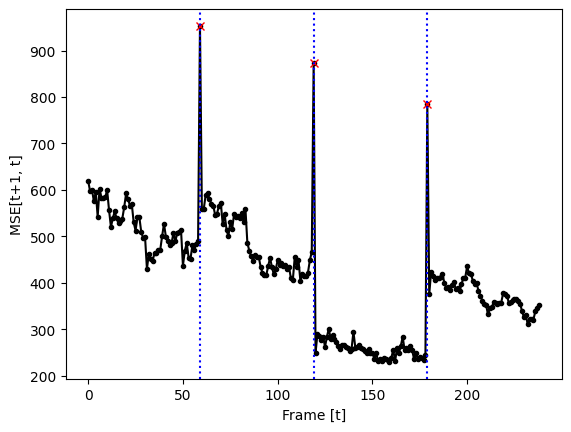

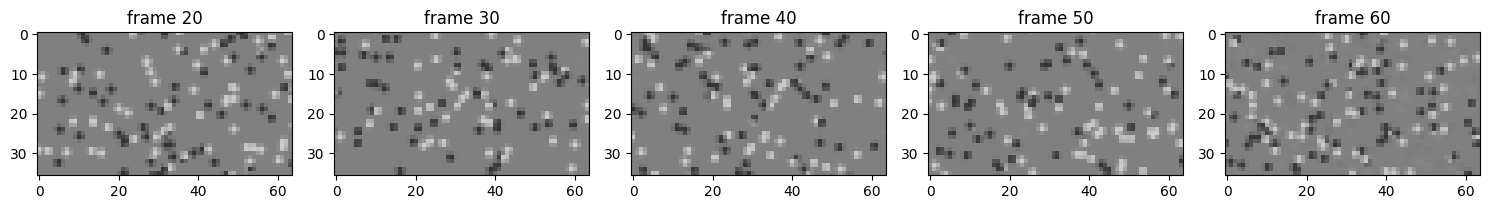

In [10]:
# rec = 'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce'
# trial = '278'
rec = 'dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20'
trial = '652'
video = ds.load_video_by_trial(rec, trial)

# plot the changes in the video
fig, ax = video.plot_changes()

# plot some frames
frames_plot = np.arange(20, 70, 10).tolist()
fig, ax = video.plot_frames(frames_plot)


## Check class occurrences

### Compute the number of occurrences for each class across all recordings

Number of occurences across all recordings:
           label  count
0   NaturalVideo   5261
1     RandomDots    467
2      PinkNoise    356
3  NaturalImages    356
4    GaussianDot    353
5          Gabor    352


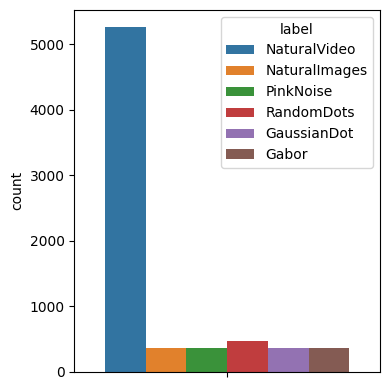

In [13]:
labels_order=["NaturalVideo", "NaturalImages", "PinkNoise","RandomDots","GaussianDot","Gabor"]

# Over all recordings
print("Number of occurences across all recordings:")
counts = trials_df["label"].value_counts()

counts_df = counts.reset_index()
counts_df.columns = ["label", "count"]
print(counts_df)

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(data=counts_df, y="count", hue="label", hue_order=labels_order, ax=ax)
fig.tight_layout()
fig.savefig(Path(repo_root, 'figures', f"count-video-labels.png"), dpi=300)
plt.show()


### Compute the number of occurrences for each class in each recording

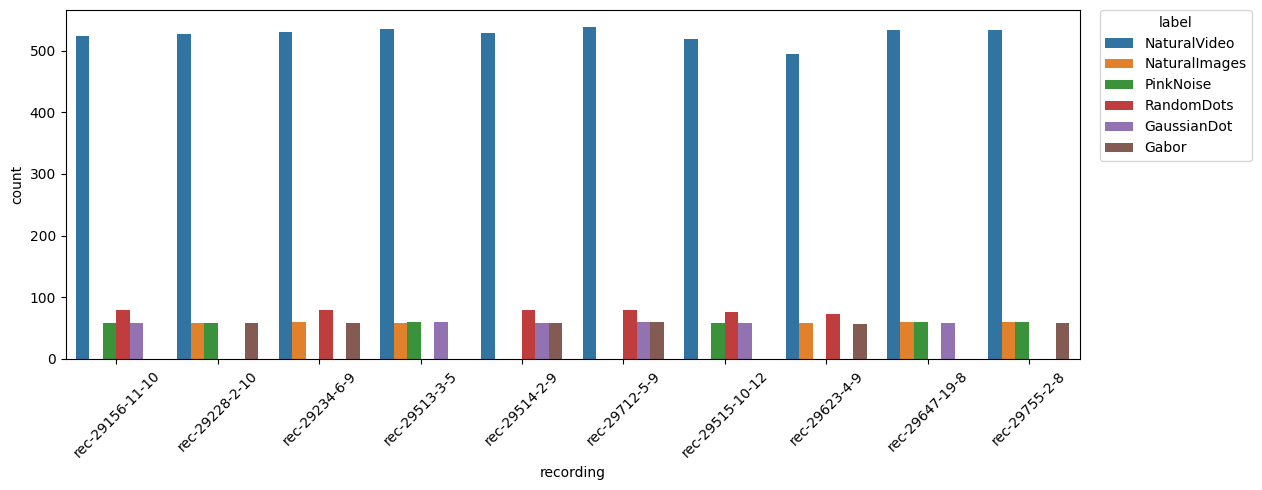

In [14]:
labels_order=["NaturalVideo", "NaturalImages", "PinkNoise","RandomDots","GaussianDot","Gabor"]
rec_order = all_recording_folders
counts = trials_df.value_counts(subset=["recording","label"])
counts_df = counts.reset_index()
counts_df.columns = ["recording", "label", "count"]

rec_order = [mapping[rec] for rec in all_recording_folders]
counts_df["recording_short_label"] = counts_df["recording"].map(mapping)

fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(data=counts_df, x="recording_short_label", y="count", hue="label", order=rec_order, hue_order=labels_order, ax=ax)
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel("recording")
ax.legend(
    title="label",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)
fig.tight_layout(rect=[0, 0, 0.85, 1])
fig.savefig(Path(repo_root, 'figures', f"count-video-labels_x-recording.png"), dpi=300)
plt.show()


### Compute class occurrences for each phase of each recording


Number of occurences for recording dynamic29156-11-10...


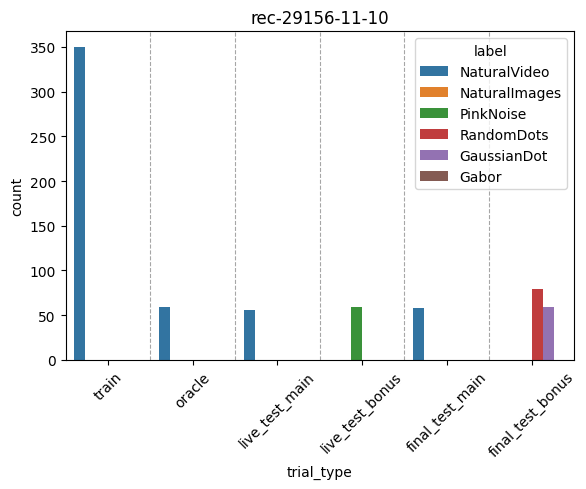


Number of occurences for recording dynamic29228-2-10-...


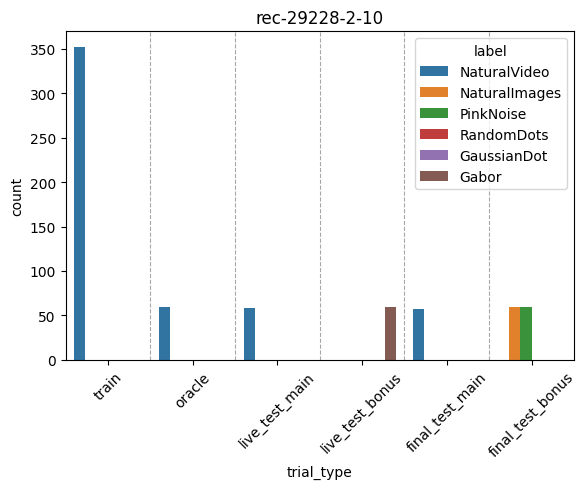


Number of occurences for recording dynamic29234-6-9-V...


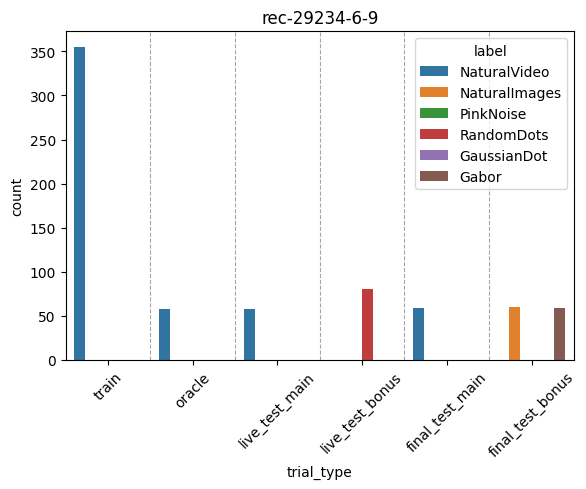


Number of occurences for recording dynamic29513-3-5-V...


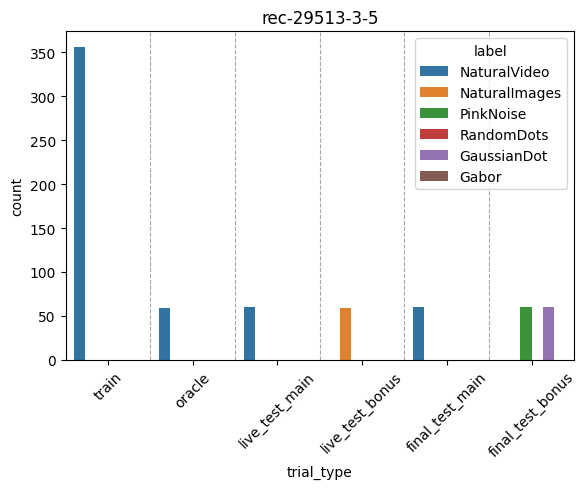


Number of occurences for recording dynamic29514-2-9-V...


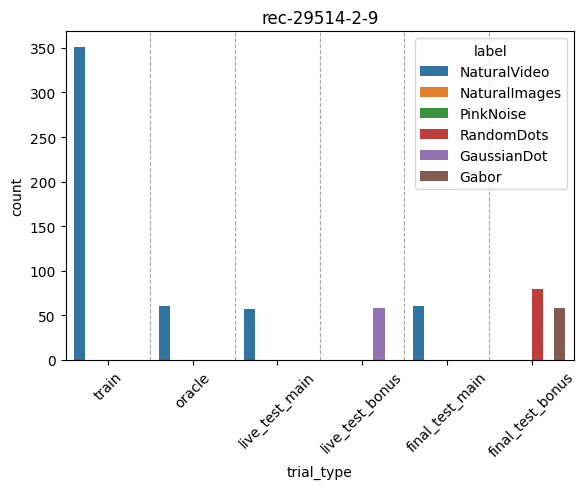


Number of occurences for recording dynamic29712-5-9-V...


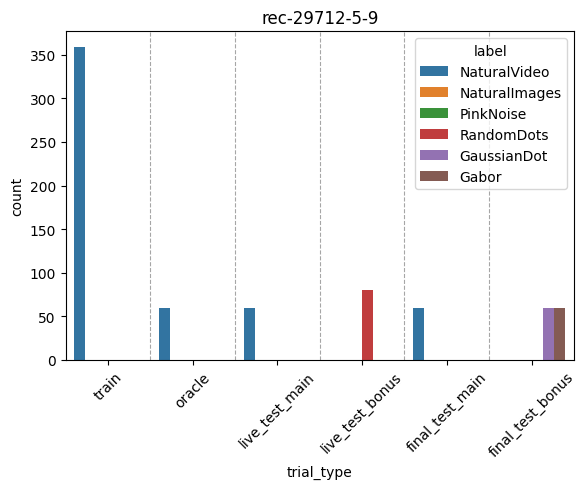


Number of occurences for recording dynamic29515-10-12...


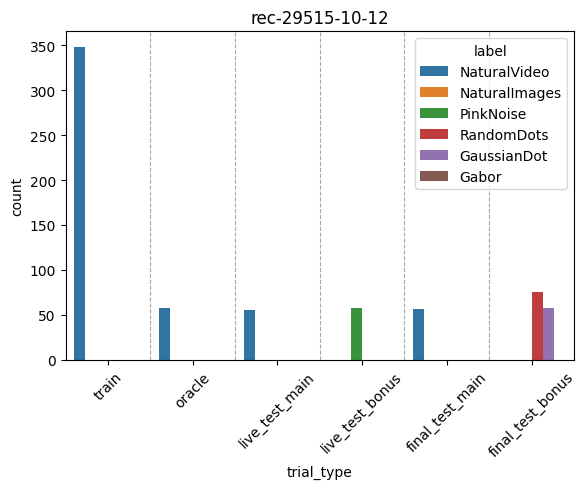


Number of occurences for recording dynamic29623-4-9-V...


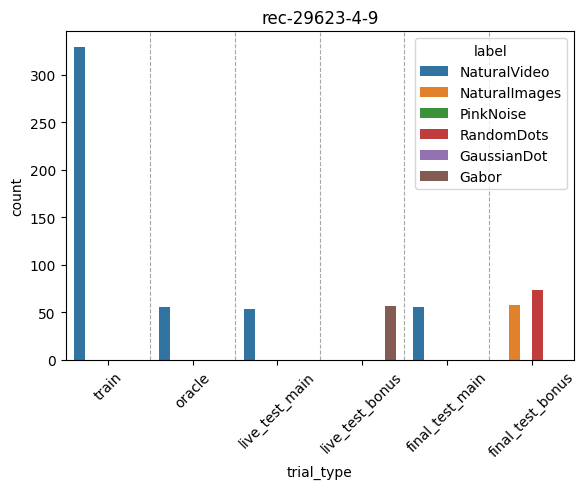


Number of occurences for recording dynamic29647-19-8-...


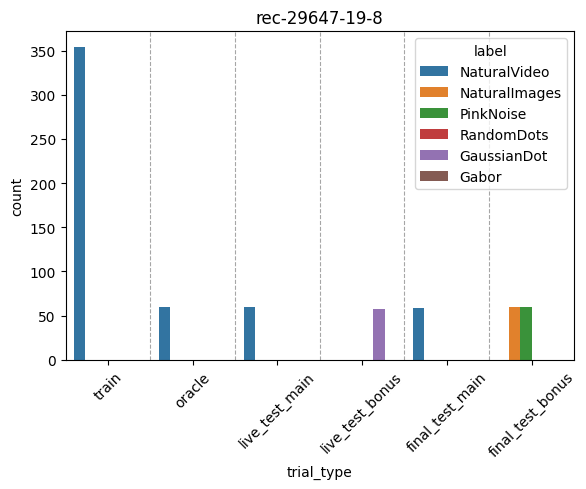


Number of occurences for recording dynamic29755-2-8-V...


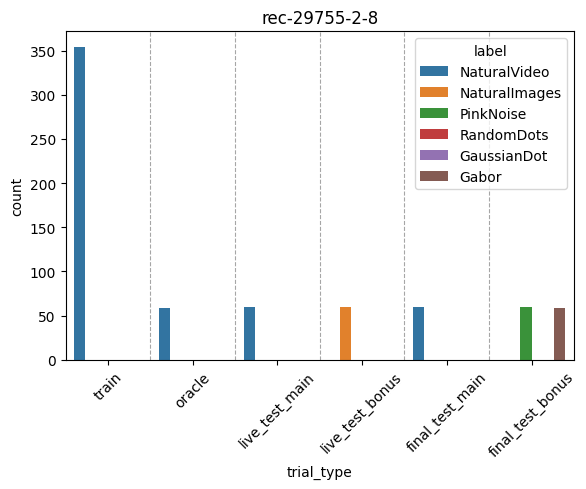

In [15]:
labels_order=["NaturalVideo", "NaturalImages", "PinkNoise","RandomDots","GaussianDot","Gabor"]
trials_order = ["train", "oracle","live_test_main","live_test_bonus","final_test_main","final_test_bonus"]

for recording_folder in all_recording_folders:
    print('\n=============================================')
    print(f'Number of occurences for recording {recording_folder[0:18]}...')
    df = trials_df[trials_df['recording']==recording_folder]
    counts = df.value_counts(subset=["label","trial_type"])
    
    counts_df = counts.reset_index()
    counts_df.columns = ["label","trial_type", "count"]

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.barplot(data=counts_df, x="trial_type", y="count", hue="label", order=trials_order, hue_order=labels_order)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"{mapping[recording_folder]}")
    # Add vertical lines between x groups
    n_groups = len(counts_df["trial_type"].unique())
    for i in range(n_groups - 1):
        ax.axvline(x=i + 0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

    # save and show
    fig.tight_layout()
    fig.savefig(Path(repo_root, 'figures', f"count-video-labels_{mapping[recording_folder]}_x-trialtype.png"), dpi=300)
    plt.show()

## Show examples for each class

### Gabor

Video label: Gabor


,frame_start,frame_end,duration,transition_start,transition_end,max_change,is_static,intensity_range,margin_left,margin_right,margin_top,margin_bottom,background_color,background_proportion,is_uniform,bad_properties
0,0,25,25,0,0,82.268126,False,216.629059,22,22,8,8,128.0,0.640643,False,False
1,25,50,25,0,0,37.135865,True,216.591492,22,22,8,8,128.0,0.644274,False,False
2,50,75,25,0,0,107.286536,False,188.393524,23,23,9,9,128.0,0.645139,False,False
3,75,100,25,0,0,4.588686,True,219.687424,22,22,9,9,128.0,0.640971,False,False
4,100,125,25,0,0,12.690914,True,223.186203,22,22,8,8,128.0,0.638014,False,False
5,125,150,25,0,0,78.631065,False,212.224655,22,22,8,8,128.0,0.640383,False,False
6,150,175,25,0,0,36.442256,True,214.120697,22,22,8,8,128.0,0.639709,False,False
7,175,200,25,0,0,100.398967,False,182.283936,23,23,9,9,128.0,0.649047,False,False
8,200,225,25,0,0,36.257088,True,214.234909,22,22,8,8,128.0,0.640228,False,False
9,225,251,26,0,0,97.622766,False,181.393387,23,23,9,9,128.0,0.647064,False,False


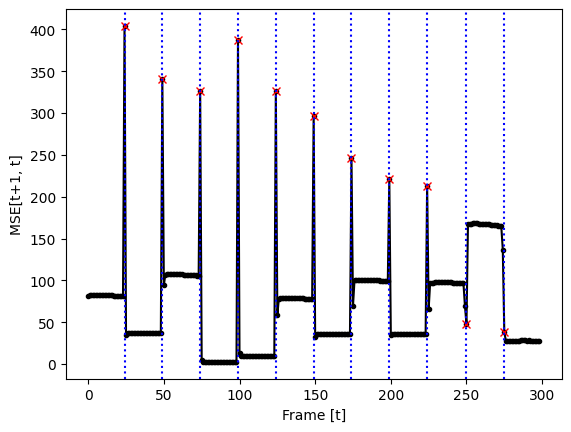

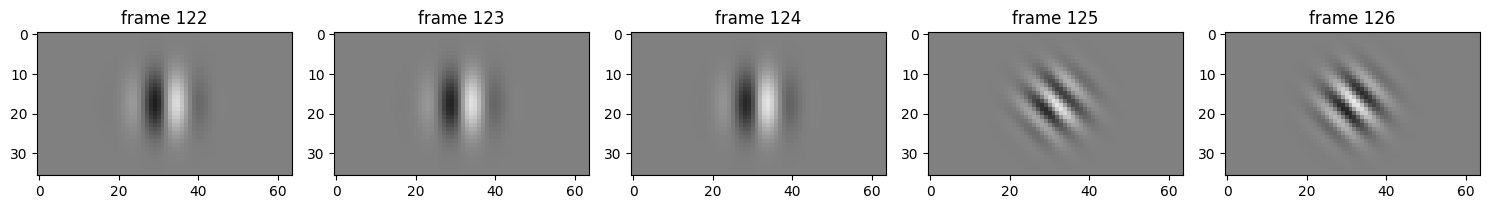

In [16]:
video = ds.load_video_by_trial(all_recording_folders[4],'410')
print(f"Video label: {video.label}")
fig, ax = video.plot_changes()
fig.savefig(Path(repo_root, 'figures', f"video-changes_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)
display(video.print_segments_table())

frames_plot = np.arange(122, 127).tolist()
fig, ax = video.plot_frames(frames_plot)
fig.savefig(Path(repo_root, 'figures', f"video-frames_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)


### Gaussian Dot

Video label: GaussianDot


,frame_start,frame_end,duration,transition_start,transition_end,max_change,is_static,intensity_range,margin_left,margin_right,margin_top,margin_bottom,background_color,background_proportion,is_uniform,bad_properties
0,0,9,9,0,0,0.000000,True,126.265625,28,22,21,1,128.0,0.769546,False,False
1,9,18,9,0,0,0.083504,True,126.453125,15,34,4,17,128.0,0.738322,False,False
2,18,27,9,0,0,0.340587,True,129.825241,44,5,1,20,128.0,0.729675,False,False
3,27,36,9,0,0,0.771252,True,129.620270,25,24,4,17,128.0,0.732125,False,False
4,36,45,9,0,0,1.364606,True,132.390640,47,2,4,17,128.0,0.725160,False,False
5,45,54,9,0,0,2.147251,True,132.156708,28,21,7,14,128.0,0.718243,False,False
6,54,63,9,0,0,0.688730,True,126.453125,31,18,4,17,128.0,0.743174,False,False
7,63,72,9,0,0,4.651830,True,134.706406,28,21,17,4,128.0,0.686443,False,False
8,72,81,9,0,0,2.574079,True,126.906250,31,18,11,10,128.0,0.666267,False,False
9,81,90,9,0,0,6.675504,True,127.453125,18,31,1,20,128.0,0.712719,False,False


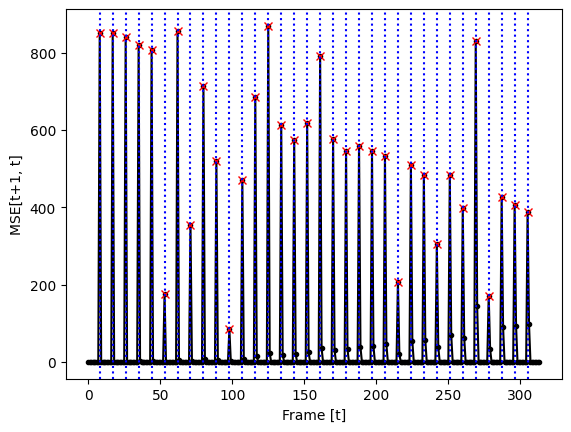

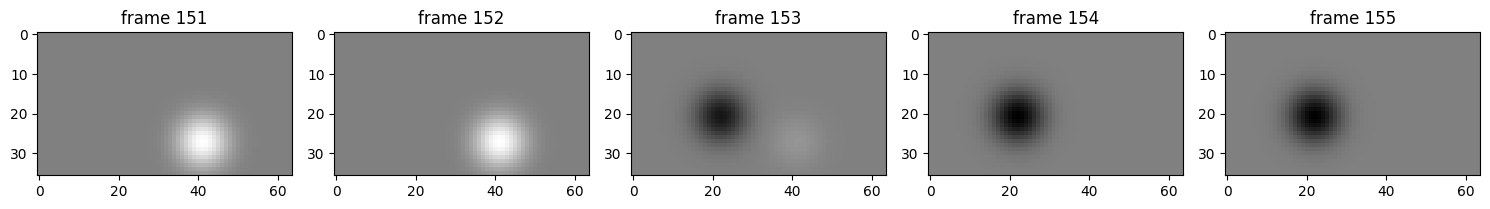

In [20]:
video = ds.load_video_by_trial(all_recording_folders[0],'464')
print(f"Video label: {video.label}")
fig, ax = video.plot_changes()
fig.savefig(Path(repo_root, 'figures', f"video-changes_{video.label}_{mapping[video.recording]}_trial_{video.trial}.png"), dpi=300)
display(video.print_segments_table())
frames_plot = np.arange(151, 156).tolist()
fig, ax = video.plot_frames(frames_plot)
fig.savefig(Path(repo_root, 'figures', f"video-frames_{video.label}_{mapping[video.recording]}_trial_{video.trial}.png"), dpi=300)


### Random Dots

Plot an example video that was first classified as `NaturalVideo` and later as `RandomDots`.

First label: NaturalVideo
Final label: RandomDots


,frame_start,frame_end,duration,transition_start,transition_end,max_change,is_static,intensity_range,margin_left,margin_right,margin_top,margin_bottom,background_color,background_proportion,is_uniform,bad_properties
0,0,60,60,0,0,619.151090,False,153.0,0,0,0,0,128.0,0.660073,False,False
1,60,120,60,0,0,593.466056,False,153.0,0,0,0,0,128.0,0.611241,False,False
2,120,180,60,0,0,300.985460,False,153.0,0,0,0,0,128.0,0.589762,False,False
3,180,240,60,0,0,434.705958,False,153.0,0,0,0,0,128.0,0.572987,False,False


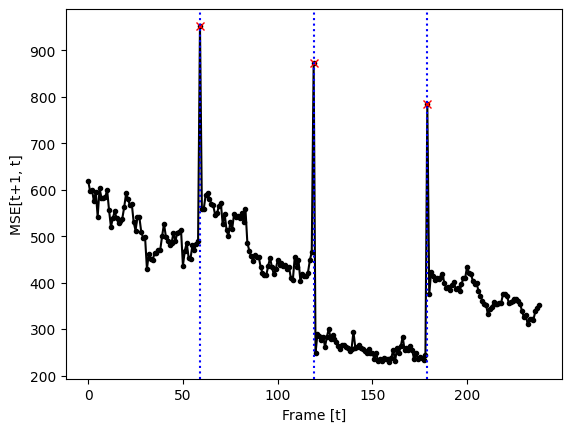

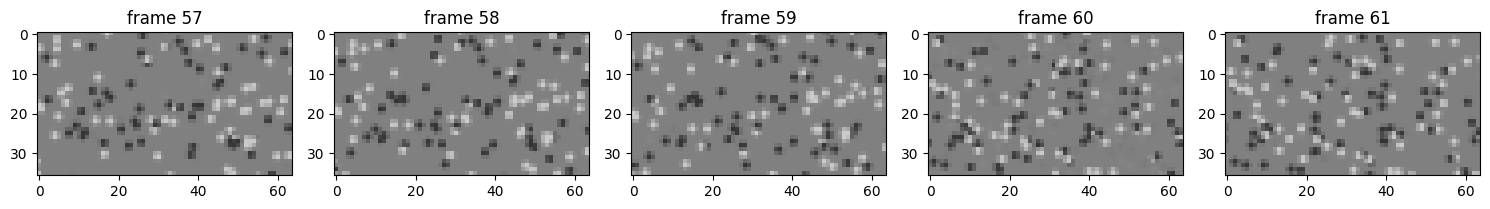

In [21]:
video = ds.load_video_by_trial(all_recording_folders[0],'386')
print(f"First label: {video.first_label}")
print(f"Final label: {video.label}")
fig, ax = video.plot_changes()
fig.savefig(Path(repo_root, 'figures', f"video-changes_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)
display(video.print_segments_table())
frames_plot = np.arange(57, 62).tolist()
fig, ax = video.plot_frames(frames_plot)
fig.savefig(Path(repo_root, 'figures', f"video-frames_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)

### Pink Noise

Video label: PinkNoise


,frame_start,frame_end,duration,transition_start,transition_end,max_change,is_static,intensity_range,margin_left,margin_right,margin_top,margin_bottom,background_color,background_proportion,is_uniform,bad_properties
0,0,27,27,0,0,457.257063,False,254.984665,0,0,0,0,131.011780,0.010360,False,False
1,27,54,27,0,0,433.702813,False,254.699066,0,0,0,0,133.019623,0.010632,False,False
2,54,81,27,0,0,491.493839,False,254.696106,0,0,0,0,138.039215,0.009735,False,False
3,81,108,27,0,0,419.912857,False,253.796432,0,0,0,0,137.035309,0.010152,False,False
4,108,135,27,0,0,461.684969,False,254.911209,0,0,0,0,134.023529,0.009992,False,False
5,135,163,28,0,0,418.256944,False,253.938263,0,0,0,0,133.019623,0.009928,False,False
6,163,189,26,0,0,399.896780,False,254.308929,0,0,0,0,133.019623,0.010958,False,False
7,189,217,28,0,0,391.345549,False,254.336319,0,0,0,0,125.992157,0.010623,False,False
8,217,243,26,0,0,390.600302,False,254.820236,0,0,0,0,115.952942,0.010276,False,False
9,243,270,27,0,0,415.028599,False,253.971909,0,0,0,0,133.019623,0.010280,False,False


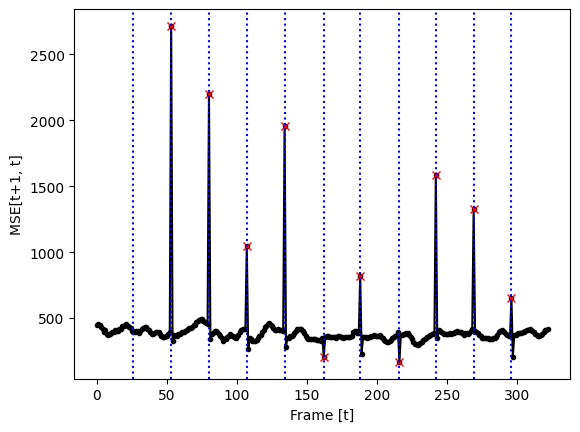

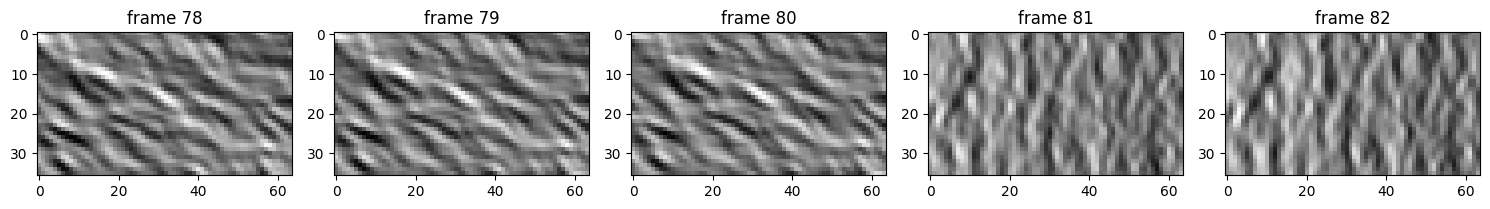

In [22]:
video = ds.load_video_by_trial('dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce', "60")
print(f"Video label: {video.label}")
fig, ax = video.plot_changes()
fig.savefig(Path(repo_root, 'figures', f"video-changes_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)
display(video.print_segments_table())
frames_plot = np.arange(78, 83).tolist()
fig, ax = video.plot_frames(frames_plot)
fig.savefig(Path(repo_root, 'figures', f"video-frames_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)


Video label: PinkNoise


,frame_start,frame_end,duration,transition_start,transition_end,max_change,is_static,intensity_range,margin_left,margin_right,margin_top,margin_bottom,background_color,background_proportion,is_uniform,bad_properties
0,0,27,27,0,0,442.264661,False,254.997406,0,0,0,0,117.960785,0.009848,False,False
1,27,54,27,0,0,480.808286,False,255.000000,0,0,0,0,137.035309,0.009159,False,False
2,54,81,27,0,0,453.283247,False,254.423752,0,0,0,0,131.011780,0.010120,False,False
3,81,108,27,0,0,418.090408,False,253.311493,0,0,0,0,142.054901,0.009960,False,False
4,108,135,27,0,0,451.281131,False,253.511505,0,0,0,0,136.031372,0.010648,False,False
5,135,162,27,0,0,409.011155,False,253.939468,0,0,0,0,133.019623,0.010168,False,False
6,162,189,27,0,0,422.674485,False,254.623276,0,0,0,0,121.976471,0.010120,False,False
7,189,216,27,0,0,404.710586,False,253.662247,0,0,0,0,121.976471,0.010152,False,False
8,216,244,28,0,0,395.865992,False,253.558945,0,0,0,0,129.003937,0.010407,False,False
9,244,270,26,0,0,413.672366,False,254.194122,0,0,0,0,130.007843,0.010143,False,False


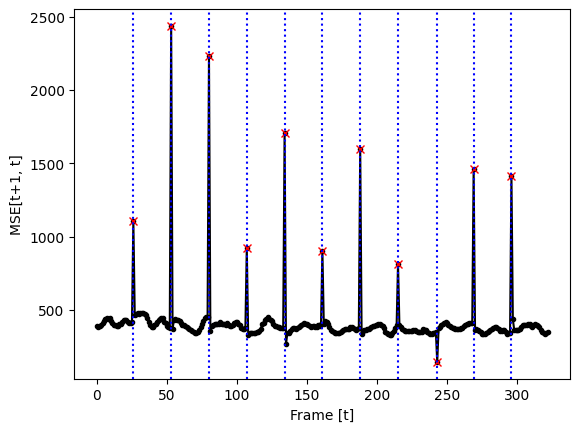

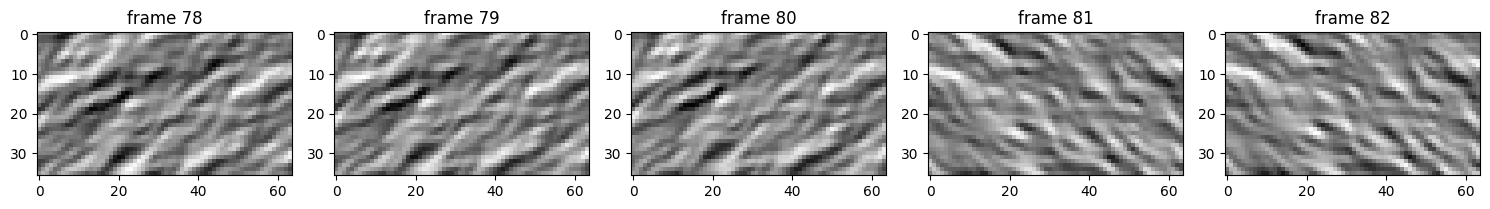

In [20]:
video = ds.load_video_by_trial(all_recording_folders[0],'633')
print(f"Video label: {video.label}")
fig, ax = video.plot_changes()
fig.savefig(Path(repo_root, 'figures', f"video-changes_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)
display(video.print_segments_table())
frames_plot = np.arange(78, 83).tolist()
fig, ax = video.plot_frames(frames_plot)
fig.savefig(Path(repo_root, 'figures', f"video-frames_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)


### Natural Video

Video label: NaturalVideo


,frame_start,frame_end,duration,transition_start,transition_end,max_change,is_static,intensity_range,margin_left,margin_right,margin_top,margin_bottom,background_color,background_proportion,is_uniform,bad_properties
0,0,222,222,0,0,656.199490,False,231.436539,0,0,0,0,136.031372,0.016995,False,False
1,222,300,78,0,0,376.581355,False,235.115341,0,0,0,0,254.494110,0.024011,False,False


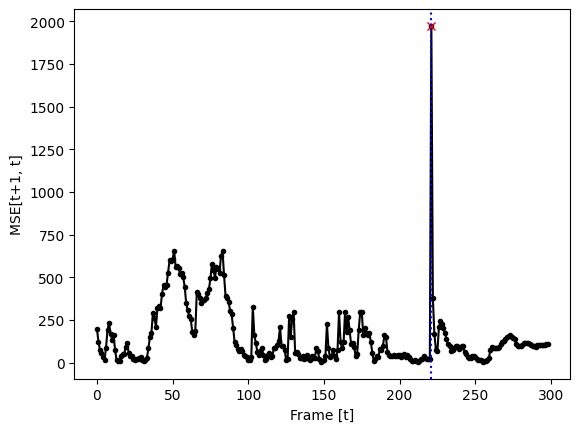

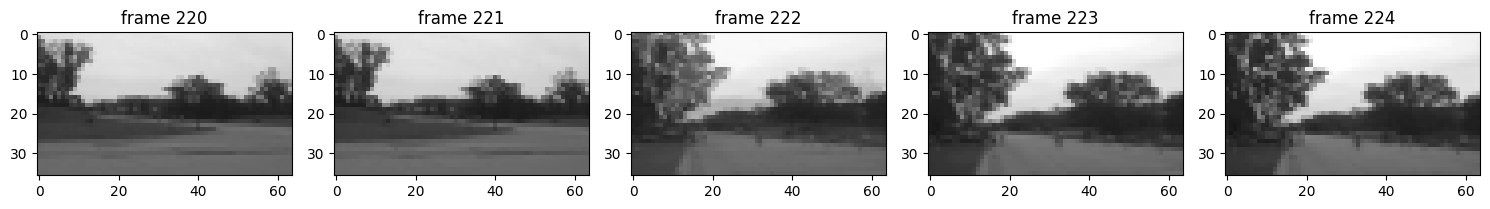

In [23]:
video = ds.load_video_by_trial(all_recording_folders[3],'35')
print(f"Video label: {video.label}")
fig, ax = video.plot_changes()
fig.savefig(Path(repo_root, 'figures', f"video-changes_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)
display(video.print_segments_table())
frames_plot = np.arange(220, 225).tolist()
fig, ax = video.plot_frames(frames_plot)
fig.savefig(Path(repo_root, 'figures', f"video-frames_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)

### Natural Images

Video label: NaturalImages


,frame_start,frame_end,duration,transition_start,transition_end,max_change,is_static,intensity_range,margin_left,margin_right,margin_top,margin_bottom,background_color,background_proportion,is_uniform,bad_properties
0,0,17,17,1,0,17.803334,True,16.352982,64,64,36,36,128.000000,0.937587,True,False
1,17,32,15,0,0,0.026276,True,245.687500,0,0,0,0,94.870590,0.019916,False,False
2,32,50,18,1,0,0.000000,True,0.000000,64,64,36,36,128.000000,0.996086,True,False
3,50,66,16,1,0,18.795763,True,201.125000,0,0,0,0,243.450989,0.020579,False,False
4,66,79,13,0,0,0.528931,True,1.996971,64,64,36,36,128.000000,0.943841,True,False
5,79,95,16,1,0,6.258757,True,210.250000,0,0,0,0,98.886276,0.012711,False,False
6,95,109,14,0,0,7.987018,True,11.676849,64,64,36,36,128.000000,0.903043,True,False
7,109,124,15,0,0,0.773072,True,221.500000,0,0,0,0,75.796082,0.021501,False,False
8,124,141,17,1,0,0.000000,True,0.000000,64,64,36,36,128.000000,0.996086,True,False
9,141,157,16,1,0,4.890777,True,248.687500,0,0,0,0,80.815689,0.017495,False,False


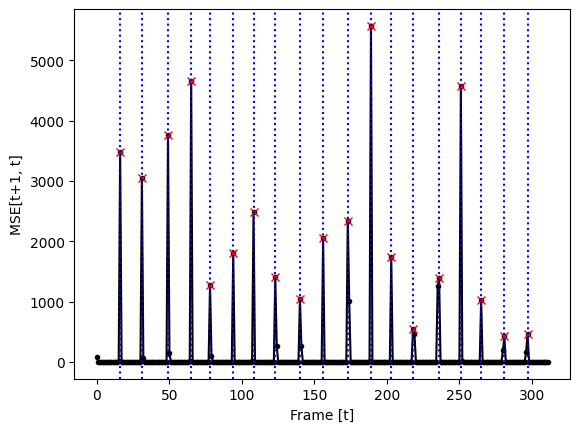

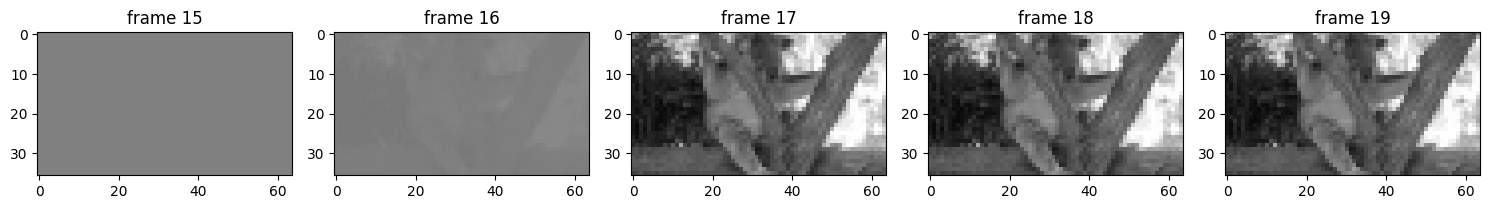

In [24]:
video = ds.load_video_by_trial(all_recording_folders[3],'660')
print(f"Video label: {video.label}")
fig, ax = video.plot_changes()
fig.savefig(Path(repo_root, 'figures', f"video-changes_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)
display(video.print_segments_table())
frames_plot = np.arange(15, 20).tolist()
fig, ax = video.plot_frames(frames_plot)
fig.savefig(Path(repo_root, 'figures', f"video-frames_{video.label}_{mapping[video.recording]}_trial-{video.trial}.png"), dpi=300)